<a href="https://colab.research.google.com/github/Tiffanyxxx3238/CPE-practice/blob/main/new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving poop_dataset.zip to poop_dataset.zip


In [2]:
import zipfile
import os

# 正確的 Colab 上傳路徑（根據你畫面中顯示）
zip_path = "/content/poop_dataset.zip"
extract_path = "/content/poop_dataset"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# 查看是否正確解壓
os.listdir(extract_path)

['poop_dataset']

In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="miOFIqynkpa1USeynCbr")
project = rf.workspace("poop-jco9f").project("poopalooza_tiff-2")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 122.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Poopalooza_Tiff-2-1 in yolov8:: 100%|██████████| 2730/2730 [00:00<00:00, 7875.81it/s]


In [4]:
import os
from pathlib import Path
import shutil

# 路徑設定
source_path = Path("/content/Poopalooza_Tiff-2-1")
target_path = Path("/content/poop_converted_3class")
target_path.mkdir(exist_ok=True)

# 三類對應：原始 7 類 → 三類
convert_map = {
    0: 0,  # BSFS 1 → Constipated
    1: 0,  # BSFS 2 → Constipated
    2: 1,  # BSFS 3 → Normal
    3: 1,  # BSFS 4 → Normal
    4: 1,  # BSFS 5 → Normal
    5: 2,  # BSFS 6 → Loose
    6: 2   # BSFS 7 → Loose
}

# 複製資料集結構與轉換標籤
for split in ["train", "valid", "test"]:
    (target_path / split / "images").mkdir(parents=True, exist_ok=True)
    (target_path / split / "labels").mkdir(parents=True, exist_ok=True)

    src_img_dir = source_path / split / "images"
    src_lbl_dir = source_path / split / "labels"
    tgt_img_dir = target_path / split / "images"
    tgt_lbl_dir = target_path / split / "labels"

    for label_file in os.listdir(src_lbl_dir):
        # 讀取原始標籤
        label_path = src_lbl_dir / label_file
        with open(label_path, 'r') as f:
            lines = f.readlines()

        converted_lines = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            class_id = int(parts[0])
            if class_id not in convert_map:
                continue
            new_class_id = convert_map[class_id]
            converted_line = f"{new_class_id} " + " ".join(parts[1:]) + "\n"
            converted_lines.append(converted_line)

        # 如果該圖片有有效物件才複製
        if converted_lines:
            # 複製圖片
            img_filename = label_file.replace(".txt", ".jpg")
            shutil.copy(src_img_dir / img_filename, tgt_img_dir / img_filename)

            # 儲存新標籤
            with open(tgt_lbl_dir / label_file, 'w') as f:
                f.writelines(converted_lines)


In [5]:
yaml_content = """
train: /content/poop_converted_3class/train/images
val: /content/poop_converted_3class/valid/images
test: /content/poop_converted_3class/test/images

nc: 3
names: ['Constipated', 'Normal', 'Loose']
"""

with open("/content/poop_converted_3class/data.yaml", "w") as f:
    f.write(yaml_content)

print("✅ 轉換完成！data.yaml 已建立好")


✅ 轉換完成！data.yaml 已建立好


In [6]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.5/983.5 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninst

In [7]:
import os
import shutil
import random
from pathlib import Path
from collections import defaultdict

# 原始路徑：三類轉換後的 yolov8 格式資料
source_path = Path("/content/poop_converted_3class")
balanced_path = Path("/content/poop_balanced_3class")
balanced_path.mkdir(parents=True, exist_ok=True)

# 每類保留最多多少張圖片（你可以改成 300、400）
max_per_class = 200

# 建立新目錄結構
for split in ["train", "valid", "test"]:
    for subdir in ["images", "labels"]:
        (balanced_path / split / subdir).mkdir(parents=True, exist_ok=True)

# 建立 class 對應的 label 檔案清單
class_to_files = defaultdict(list)

for split in ["train", "valid", "test"]:
    label_dir = source_path / split / "labels"
    for file in os.listdir(label_dir):
        with open(label_dir / file, 'r') as f:
            content = f.read().strip()
        if not content:
            continue
        class_id = int(content.split()[0])
        class_to_files[(split, class_id)].append(file)

# 將每類限制最多 max_per_class 張，複製圖 + 標籤
for (split, cls), files in class_to_files.items():
    selected = random.sample(files, min(max_per_class, len(files)))
    for file in selected:
        # 複製 label
        src_lbl = source_path / split / "labels" / file
        dst_lbl = balanced_path / split / "labels" / file
        shutil.copy(src_lbl, dst_lbl)

        # 複製對應圖片
        img_file = file.replace(".txt", ".jpg")
        src_img = source_path / split / "images" / img_file
        dst_img = balanced_path / split / "images" / img_file
        if src_img.exists():
            shutil.copy(src_img, dst_img)

# 建立新的 data.yaml
yaml_content = """
train: /content/poop_balanced_3class/train/images
val: /content/poop_balanced_3class/valid/images
test: /content/poop_balanced_3class/test/images

nc: 3
names: ['Constipated', 'Normal', 'Loose']
"""

with open(balanced_path / "data.yaml", "w") as f:
    f.write(yaml_content)

print("✅ 已完成平衡後的三類資料集建立，準備進行 YOLOv8 訓練！")


✅ 已完成平衡後的三類資料集建立，準備進行 YOLOv8 訓練！


In [8]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")  # 你也可以選 yolov8n.pt 節省資源
model.train(
    data="/content/poop_balanced_3class/data.yaml",
    epochs=100,
    imgsz=640
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 49.7M/49.7M [00:00<00:00, 242MB/s]


Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/poop_balanced_3class/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=Tru

100%|██████████| 755k/755k [00:00<00:00, 14.1MB/s]

Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

...

                   all        269        654       0.84      0.747      0.821      0.675



100 epochs completed in 0.627 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/train/weights/best.pt, 52.0MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:03<00:00,  2.35it/s]


                   all        269        654       0.83      0.743      0.819      0.676
           Constipated         46        170      0.884      0.849      0.911      0.761
                Normal        126        283      0.812      0.658      0.753      0.609
                 Loose        116        201      0.795      0.721      0.792      0.658
Speed: 0.2ms preprocess, 9.9ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ac4dc752910>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [9]:
!pip install ultralytics --upgrade
from ultralytics import YOLO
import numpy as np

In [10]:
model = YOLO("runs/detect/train/weights/best.pt")

In [11]:
metrics = model.val(data="poop_balanced_3class/data.yaml", save_json=True)

Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1616.0±503.1 MB/s, size: 36.4 KB)


val: Scanning /content/poop_balanced_3class/valid/labels.cache... 269 images, 0 backgrounds, 0 corrupt: 100%|██████████| 269/269 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:07<00:00,  2.18it/s]


                   all        269        654      0.831      0.744      0.819      0.677
           Constipated         46        170      0.884      0.851      0.911       0.76
                Normal        126        283      0.812      0.658      0.753       0.61
                 Loose        116        201      0.795      0.721      0.793       0.66
Speed: 0.9ms preprocess, 22.3ms inference, 0.0ms loss, 0.9ms postprocess per image
Saving runs/detect/val/predictions.json...
Results saved to runs/detect/val


In [12]:
conf_matrix = metrics.confusion_matrix.matrix
class_names = model.names

total_TP = total_FP = total_TN = total_FN = 0

for i, name in enumerate(class_names):
    TP = conf_matrix[i, i]
    FP = conf_matrix[:, i].sum() - TP
    FN = conf_matrix[i, :].sum() - TP
    TN = conf_matrix.sum() - (TP + FP + FN)

    total_TP += TP
    total_FP += FP
    total_FN += FN
    total_TN += TN

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    specificity = TN / (TN + FP + 1e-6)
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-6)
    f1_score = 2 * precision * recall / (precision + recall + 1e-6)

    print(f"📌 類別 [{name}]")
    print(f"  Precision  : {precision:.4f}")
    print(f"  Recall     : {recall:.4f}")
    print(f"  Specificity: {specificity:.4f}")
    print(f"  Accuracy   : {accuracy:.4f}")
    print(f"  F1 Score   : {f1_score:.4f}")
    print()

📌 類別 [0]
  Precision  : 0.8588
  Recall     : 0.7449
  Specificity: 0.9617
  Accuracy   : 0.9101
  F1 Score   : 0.7978

📌 類別 [1]
  Precision  : 0.6961
  Recall     : 0.6747
  Specificity: 0.8380
  Accuracy   : 0.7801
  F1 Score   : 0.6852

📌 類別 [2]
  Precision  : 0.7264
  Recall     : 0.6759
  Specificity: 0.9094
  Accuracy   : 0.8481
  F1 Score   : 0.7002



In [13]:
overall_precision = total_TP / (total_TP + total_FP + 1e-6)
overall_recall = total_TP / (total_TP + total_FN + 1e-6)
overall_specificity = total_TN / (total_TN + total_FP + 1e-6)
overall_accuracy = (total_TP + total_TN) / (total_TP + total_FP + total_FN + total_TN + 1e-6)
overall_f1 = 2 * overall_precision * overall_recall / (overall_precision + overall_recall + 1e-6)

print("🔎📊 整體（Overall）指標")
print(f"  Overall Precision  : {overall_precision:.4f}")
print(f"  Overall Recall     : {overall_recall:.4f}")
print(f"  Overall Specificity: {overall_specificity:.4f}")
print(f"  Overall Accuracy   : {overall_accuracy:.4f}")
print(f"  Overall F1 Score   : {overall_f1:.4f}")

🔎📊 整體（Overall）指標
  Overall Precision  : 0.7477
  Overall Recall     : 0.6946
  Overall Specificity: 0.9065
  Overall Accuracy   : 0.8461
  Overall F1 Score   : 0.7202


In [14]:
import os

for root, dirs, files in os.walk("/content/poop_balanced_3class"):
    print(f"\n📁 目錄: {root}")
    for d in dirs:
        print(f"  📂 {d}")
    for f in files[:5]:  # 最多顯示前5個檔案
        print(f"  🖼️ {f}")


📁 目錄: /content/poop_balanced_3class
  📂 valid
  📂 train
  📂 test
  🖼️ data.yaml

📁 目錄: /content/poop_balanced_3class/valid
  📂 labels
  📂 images
  🖼️ labels.cache

📁 目錄: /content/poop_balanced_3class/valid/labels
  🖼️ 621_jpg.rf.5cd54314bae2f1a4aec6e02c576554fa.txt
  🖼️ 45_jpg.rf.cc96f1421bf42449035123856f4af49a.txt
  🖼️ 387.rf.6688ba640a4f4d95d40e184b5c40979f.txt
  🖼️ 395_jpg.rf.d0ef3cb30545e647c3dfc3bd988979e3.txt
  🖼️ 1349.rf.4b98381fb6e7d894016e62ad187141d1.txt

📁 目錄: /content/poop_balanced_3class/valid/images
  🖼️ 189.rf.32a99c95e082f6d1f8d0dbe944c9e421.jpg
  🖼️ 113_jpg.rf.8f3671c222138ff459dbbc817290f859.jpg
  🖼️ 1018_jpg.rf.99dd40d083ac1983d9b0828e289995b7.jpg
  🖼️ 1036_jpg.rf.85a532a2d18020585e890ca130516a77.jpg
  🖼️ 254_jpg.rf.0750581528ef8e58510018dade2c1589.jpg

📁 目錄: /content/poop_balanced_3class/train
  📂 labels
  📂 images
  🖼️ labels.cache

📁 目錄: /content/poop_balanced_3class/train/labels
  🖼️ 257_jpg.rf.76a93a5a44a3a47545cd1ddc5ce7fb92.txt
  🖼️ 1054_jpg.rf.5adb5b146682a

In [15]:
from ultralytics import YOLO
import os

# 使用你剛訓練好的最佳模型
model = YOLO("runs/detect/train/weights/best.pt")  # ← 這路徑應該無誤

# 輸入圖片資料夾（可以選 valid 或 train 或 test）
input_folder = "/content/poop_balanced_3class/valid/images"

# 建立存放資料夾（images + masks + labels.txt）
output_dir = "/content/poop_segment_dataset"
os.makedirs(f"{output_dir}/images", exist_ok=True)
os.makedirs(f"{output_dir}/masks", exist_ok=True)
os.makedirs(f"{output_dir}/labels", exist_ok=True)

In [16]:
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install supervision opencv-python

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-n9637ey9
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-n9637ey9
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=e876f2bd33ab0d3e185299f6af21c199cffae1e63d7f6cf0fca2fc6fe31970de
  Stored in directory: /tmp/pip-ephem-wheel-cache-u48xnbmv/wheels/15/d7/bd/05f5f23b7dcbe70cbc6783b06f12143b0cf1a5da5c7b52dcc5
Successfully built segment_anything
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 4.1 MB/s eta 0:00:00


In [17]:
from ultralytics import YOLO
from segment_anything import sam_model_registry, SamPredictor
import torch
import supervision as sv
import cv2
import numpy as np
import os
from PIL import Image

# 載入 YOLOv8 偵測模型
yolo_model = YOLO("/content/runs/detect/train/weights/best.pt")

# 下載並載入 SAM 模型（vit_b 為中等大小）
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
sam_checkpoint = "sam_vit_b_01ec64.pth"
sam = sam_model_registry["vit_b"](checkpoint=sam_checkpoint)
sam.to("cuda")
predictor = SamPredictor(sam)

--2025-04-24 10:31:43--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.173.166.31, 18.173.166.74, 18.173.166.48, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.173.166.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   150MB/s    in 2.4s    

2025-04-24 10:31:46 (150 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [18]:
# 輸入影像資料夾
input_folder = "/content/poop_balanced_3class/train/images"

# 輸出遮罩與圖片資料夾（將會自動建立）
output_image_dir = "/content/sam_output/images"
output_mask_dir = "/content/sam_output/masks"
output_label_file = "/content/sam_output/labels.txt"

os.makedirs(output_image_dir, exist_ok=True)
os.makedirs(output_mask_dir, exist_ok=True)

In [19]:
from ultralytics import YOLO
from PIL import Image
import os
import cv2
import numpy as np

# 設定路徑
model_path = "runs/detect/train/weights/best.pt"
image_folder = "/content/poop_balanced_3class/valid/images"
output_folder = "/content/yolo_outputs"
os.makedirs(output_folder, exist_ok=True)

# 載入模型
model = YOLO(model_path)

# 預測所有圖片
results = model.predict(source=image_folder, save=False)

# 儲存每張圖的便便框
for i, result in enumerate(results):
    image_path = result.path
    boxes = result.boxes.xyxy.cpu().numpy().astype(int)
    labels = result.boxes.cls.cpu().numpy().astype(int)
    img = cv2.imread(image_path)

    # 每個框都裁一張小圖儲存（接下來 SAM 就用這個小圖）
    for j, (x1, y1, x2, y2) in enumerate(boxes):
        crop = img[y1:y2, x1:x2]
        filename = os.path.basename(image_path).replace(".jpg", f"_crop{j}.jpg")
        cv2.imwrite(os.path.join(output_folder, filename), crop)


image 1/269 /content/poop_balanced_3class/valid/images/1000_jpg.rf.28f6404065f8b051e3b48385fe211624.jpg: 640x640 1 Constipated, 1 Normal, 37.1ms
image 2/269 /content/poop_balanced_3class/valid/images/1009_jpg.rf.c5c6cc42871e0fcbeb1c4aa13506866c.jpg: 640x640 1 Normal, 36.3ms
image 3/269 /content/poop_balanced_3class/valid/images/1011_jpg.rf.a33001a0d5ca303e1cf62c374dba9f56.jpg: 640x640 1 Normal, 36.3ms
image 4/269 /content/poop_balanced_3class/valid/images/1018_jpg.rf.99dd40d083ac1983d9b0828e289995b7.jpg: 640x640 2 Constipateds, 1 Loose, 36.3ms
image 5/269 /content/poop_balanced_3class/valid/images/101_jpg.rf.9ac576bcdec70744a149f60aeb503321.jpg: 640x640 1 Loose, 36.3ms
image 6/269 /content/poop_balanced_3class/valid/images/1022_jpg.rf.349d71e7c2f815a2275d8e848c846607.jpg: 640x640 3 Constipateds, 3 Normals, 25.4ms
image 7/269 /content/poop_balanced_3class/valid/images/1025_jpg.rf.4aece4f3041fac00aae4e4e9a2c2a492.jpg: 640x640 1 Normal, 21.7ms
image 8/269 /content/poop_balanced_3class/va

In [20]:
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install opencv-python matplotlib

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-dc6r4d88
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-dc6r4d88
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor

# 下載 SAM 模型權重（可用其他 SAM 模型 variant）
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

# 載入模型
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
predictor = SamPredictor(sam)

--2025-04-24 10:32:03--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.173.166.31, 18.173.166.74, 18.173.166.48, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.173.166.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth.1’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   171MB/s    in 2.1s    

2025-04-24 10:32:05 (171 MB/s) - ‘sam_vit_b_01ec64.pth.1’ saved [375042383/375042383]



In [22]:
import os
os.makedirs("/content/poop_crops", exist_ok=True)

In [23]:
from ultralytics import YOLO
import cv2
import os

# 載入模型
model = YOLO("runs/detect/train/weights/best.pt")

# 圖片與輸出資料夾
input_folder = "/content/poop_balanced_3class/valid/images"
output_folder = "/content/poop_crops"

# 預測
results = model.predict(source=input_folder, save=False)

# 儲存每個預測框的裁切圖
for i, result in enumerate(results):
    img_path = result.path
    img_name = os.path.basename(img_path)
    image = cv2.imread(img_path)

    for j, box in enumerate(result.boxes.xyxy.cpu().numpy()):
        x1, y1, x2, y2 = map(int, box)
        crop = image[y1:y2, x1:x2]
        save_path = os.path.join(output_folder, f"{os.path.splitext(img_name)[0]}_{j}.jpg")
        cv2.imwrite(save_path, crop)



image 1/269 /content/poop_balanced_3class/valid/images/1000_jpg.rf.28f6404065f8b051e3b48385fe211624.jpg: 640x640 1 Constipated, 1 Normal, 37.0ms
image 2/269 /content/poop_balanced_3class/valid/images/1009_jpg.rf.c5c6cc42871e0fcbeb1c4aa13506866c.jpg: 640x640 1 Normal, 34.2ms
image 3/269 /content/poop_balanced_3class/valid/images/1011_jpg.rf.a33001a0d5ca303e1cf62c374dba9f56.jpg: 640x640 1 Normal, 30.5ms
image 4/269 /content/poop_balanced_3class/valid/images/1018_jpg.rf.99dd40d083ac1983d9b0828e289995b7.jpg: 640x640 2 Constipateds, 1 Loose, 30.4ms
image 5/269 /content/poop_balanced_3class/valid/images/101_jpg.rf.9ac576bcdec70744a149f60aeb503321.jpg: 640x640 1 Loose, 30.4ms
image 6/269 /content/poop_balanced_3class/valid/images/1022_jpg.rf.349d71e7c2f815a2275d8e848c846607.jpg: 640x640 3 Constipateds, 3 Normals, 30.4ms
image 7/269 /content/poop_balanced_3class/valid/images/1025_jpg.rf.4aece4f3041fac00aae4e4e9a2c2a492.jpg: 640x640 1 Normal, 30.4ms
image 8/269 /content/poop_balanced_3class/va

In [24]:
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install opencv-python matplotlib

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-u9qhehk9
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-u9qhehk9
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


In [25]:
# 建立模型資料夾
!mkdir -p /content/sam_checkpoints

# 下載 vit_b 權重檔
!wget -O /content/sam_checkpoints/sam_vit_b.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2025-04-24 10:32:22--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.173.166.51, 18.173.166.31, 18.173.166.74, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.173.166.51|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘/content/sam_checkpoints/sam_vit_b.pth’

/content/sam_checkp 100%[===================>] 357.67M   128MB/s    in 2.8s    

2025-04-24 10:32:25 (128 MB/s) - ‘/content/sam_checkpoints/sam_vit_b.pth’ saved [375042383/375042383]



In [26]:
import os
from segment_anything import SamPredictor, sam_model_registry
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 載入 SAM 模型（建議使用 Vit-B，可平衡速度與效果）
sam_checkpoint = "/content/sam_checkpoints/sam_vit_b.pth"
model_type = "vit_b"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device)
predictor = SamPredictor(sam)

input_folder = "/content/poop_crops"
output_mask_folder = "/content/poop_masks"
os.makedirs(output_mask_folder, exist_ok=True)

# 為每張圖片產生遮罩
for img_file in os.listdir(input_folder):
    if not img_file.lower().endswith((".jpg", ".png")):
        continue
    img_path = os.path.join(input_folder, img_file)
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    predictor.set_image(image)
    masks, scores, logits = predictor.predict(point_coords=None, point_labels=None, multimask_output=True)

    # 取第一個遮罩結果（可改為最 confident 的）
    mask = masks[0].astype(np.uint8) * 255
    cv2.imwrite(os.path.join(output_mask_folder, img_file.replace(".jpg", ".png")), mask)

In [27]:
import os
import shutil

base_dir = "/content/poop_seg_dataset"
image_dir = os.path.join(base_dir, "images")
mask_dir = os.path.join(base_dir, "masks")
label_file = os.path.join(base_dir, "labels.txt")

os.makedirs(image_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)

print("✅ 建立完畢：images/, masks/, labels.txt")

✅ 建立完畢：images/, masks/, labels.txt


In [28]:
import glob
import shutil
import os

# 類別對應表（根據你的資料順序）
class_id_to_name = {0: "Constipated", 1: "Normal", 2: "Loose"}

# 資料夾路徑
crop_folder = "/content/poop_crops"
mask_folder = "/content/poop_masks"
label_folders = [
    "/content/poop_balanced_3class/train/labels",
    "/content/poop_balanced_3class/valid/labels",
    "/content/poop_balanced_3class/test/labels",
]

# 目標資料夾
target_image_dir = "/content/poop_seg_dataset/images"
target_mask_dir = "/content/poop_seg_dataset/masks"
label_txt_path = "/content/poop_seg_dataset/labels.txt"

# 開始處理
with open(label_txt_path, "w") as f:
    for crop_path in glob.glob(os.path.join(crop_folder, "*.jpg")):
        basename = os.path.basename(crop_path)
        # ✅ 改：去掉 _3.jpg，只留下完整 base_name 做為 .txt 名稱
        label_base = basename.rsplit("_", 1)[0]
        mask_path = os.path.join(mask_folder, basename.replace(".jpg", ".png"))

        # 找對應的 label 檔
        label_file = None
        for folder in label_folders:
            candidate = os.path.join(folder, label_base + ".txt")
            if os.path.exists(candidate):
                label_file = candidate
                break

        if label_file is None:
            print(f"⚠️ 找不到 label：{basename}（對應 {label_base}.txt）")
            continue

        # 複製圖片與遮罩
        shutil.copy(crop_path, os.path.join(target_image_dir, basename))
        shutil.copy(mask_path, os.path.join(target_mask_dir, basename.replace(".jpg", ".png")))

        # 讀 label，統計哪個類別最多
        with open(label_file, "r") as lf:
            lines = lf.readlines()
            class_counts = {}
            for line in lines:
                parts = line.strip().split()
                if len(parts) > 0:
                    cls_id = int(float(parts[0]))
                    class_counts[cls_id] = class_counts.get(cls_id, 0) + 1

            if class_counts:
                major_class_id = max(class_counts, key=class_counts.get)
                f.write(f"{basename} {class_id_to_name[major_class_id]}\n")
            else:
                print(f"⚠️ label 空白：{basename}，跳過")


In [29]:
yaml_path = "/content/poop_seg_dataset/data.yaml"

with open(yaml_path, "w") as f:
    f.write(
        "train: /content/poop_seg_dataset/images\n"
        "val: /content/poop_seg_dataset/images\n"
        "\n"
        "names:\n"
        "  0: Constipated\n"
        "  1: Normal\n"
        "  2: Loose\n"
    )

print(f"✅ 建立完成: {yaml_path}")

✅ 建立完成: /content/poop_seg_dataset/data.yaml


In [30]:
import os
import cv2
import numpy as np

image_dir = "/content/poop_seg_dataset/images"
mask_dir = "/content/poop_seg_dataset/masks"
labels_txt = "/content/poop_seg_dataset/labels.txt"
output_label_dir = "/content/poop_seg_dataset/labels"
os.makedirs(output_label_dir, exist_ok=True)

# 類別名稱 → 數字映射
class_to_index = {
    "Constipated": 0,
    "Normal": 1,
    "Loose": 2,
}

# 建立檔名對應類別 index
label_map = {}
with open(labels_txt, "r") as f:
    for line in f:
        name, cls = line.strip().split()
        if cls not in class_to_index:
            print(f"⚠️ 類別錯誤：{cls}（跳過）")
            continue
        label_map[name] = class_to_index[cls]

count = 0
for filename in os.listdir(mask_dir):
    if not filename.endswith(".png"):
        continue

    name = filename.replace(".png", ".jpg")
    if name not in label_map:
        print(f"⚠️ 找不到 label：{name}（跳過）")
        continue

    mask_path = os.path.join(mask_dir, filename)
    img_path = os.path.join(image_dir, name)
    if not os.path.exists(img_path):
        print(f"⚠️ 找不到對應圖片：{img_path}（跳過）")
        continue

    cls = label_map[name]
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    h, w = mask.shape
    txt_path = os.path.join(output_label_dir, name.replace(".jpg", ".txt"))
    with open(txt_path, "w") as f:
        for contour in contours:
            if len(contour) < 3:
                continue
            points = contour.squeeze().astype(float)
            if points.ndim != 2:
                continue
            points[:, 0] /= w
            points[:, 1] /= h
            points = points.flatten()
            line = f"{cls} " + " ".join([f"{p:.6f}" for p in points])
            f.write(line + "\n")
    count += 1

print(f"✅ 成功建立 {count} 筆 YOLOv8 segmentation labels")

✅ 成功建立 682 筆 YOLOv8 segmentation labels


In [31]:
from ultralytics import YOLO

# 使用 yolov8n-seg 開始重新訓練
model = YOLO("yolov8n-seg.pt")
model.train(
    data="/content/poop_seg_dataset/data.yaml",
    epochs=100,
    imgsz=640,
    cache=True,
    project="poop_seg_retrain",
    name="yolov8n-seg-v2",
    batch=8,
    device=0  # 如果你是用 Colab Pro，就可以指定使用 GPU:0
)

100%|██████████| 6.74M/6.74M [00:00<00:00, 79.8MB/s]


Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=segment, mode=train, model=yolov8n-seg.pt, data=/content/poop_seg_dataset/data.yaml, epochs=100, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=True, device=0, workers=8, project=poop_seg_retrain, name=yolov8n-seg-v2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=Tru

train: Scanning /content/poop_seg_dataset/labels... 680 images, 44 backgrounds, 2 corrupt: 100%|██████████| 682/682 [00:00<00:00, 852.99it/s]

train: /content/poop_seg_dataset/images/735_jpg.rf.3a02d6bffe3fe4ae8f3f8836ac343a4f_5.jpg: ignoring corrupt image/label: image size (9, 14) <10 pixels
train: /content/poop_seg_dataset/images/735_jpg.rf.3a02d6bffe3fe4ae8f3f8836ac343a4f_6.jpg: ignoring corrupt image/label: image size (8, 11) <10 pixels
train: New cache created: /content/poop_seg_dataset/labels.cache


WARNING ⚠️ cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):   5%|▍         | 2/43 [00:00<00:16,  2.44it/s]

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 43/43 [00:07<00:00,  5.50it/s]


                   all        680      14999      0.588      0.084     0.0879     0.0689       0.53     0.0705     0.0726     0.0439
           Constipated        164       1853      0.549      0.157      0.158      0.125      0.472      0.127      0.127     0.0772
                Normal        284       6543      0.604     0.0585     0.0641     0.0497      0.552     0.0517     0.0539     0.0328
                 Loose        188       6603      0.611     0.0371     0.0413     0.0323      0.566     0.0332     0.0365     0.0216
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to poop_seg_retrain/yolov8n-seg-v2


ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ac5aed38990>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04

In [32]:
from ultralytics import YOLO

# 載入訓練好的語意分割模型
model = YOLO("/content/poop_seg_retrain/yolov8n-seg-v2/weights/best.pt")

In [33]:
# 使用 validation 資料集評估，這會自動使用 data.yaml 指定的 val 目錄
metrics = model.val(data="/content/poop_seg_dataset/data.yaml")

Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,258,649 parameters, 0 gradients, 12.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 711.5±616.5 MB/s, size: 18.4 KB)


val: Scanning /content/poop_seg_dataset/labels.cache... 680 images, 44 backgrounds, 2 corrupt: 100%|██████████| 682/682 [00:00<?, ?it/s]

train: /content/poop_seg_dataset/images/735_jpg.rf.3a02d6bffe3fe4ae8f3f8836ac343a4f_5.jpg: ignoring corrupt image/label: image size (9, 14) <10 pixels
train: /content/poop_seg_dataset/images/735_jpg.rf.3a02d6bffe3fe4ae8f3f8836ac343a4f_6.jpg: ignoring corrupt image/label: image size (8, 11) <10 pixels



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):   0%|          | 0/43 [00:00<?, ?it/s]

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image

...

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):   5%|▍         | 2/43 [00:01<00:29,  1.39it/s]

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 43/43 [00:09<00:00,  4.77it/s]


                   all        680      14999      0.583     0.0841     0.0879     0.0691      0.522     0.0704      0.072     0.0438
           Constipated        164       1853      0.543      0.157      0.158      0.125      0.458      0.126      0.126      0.077
                Normal        284       6543        0.6     0.0585     0.0642     0.0497      0.547     0.0517     0.0536     0.0328
                 Loose        188       6603      0.606     0.0374     0.0413     0.0323      0.562     0.0332     0.0365     0.0216
Speed: 0.3ms preprocess, 4.4ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/segment/val


In [34]:
import numpy as np

conf_matrix = metrics.confusion_matrix.matrix
class_names = model.names

total_TP = total_FP = total_TN = total_FN = 0

for i, name in enumerate(class_names):
    TP = conf_matrix[i, i]
    FP = conf_matrix[:, i].sum() - TP
    FN = conf_matrix[i, :].sum() - TP
    TN = conf_matrix.sum() - (TP + FP + FN)

    total_TP += TP
    total_FP += FP
    total_FN += FN
    total_TN += TN

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    specificity = TN / (TN + FP + 1e-6)
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-6)
    f1_score = 2 * precision * recall / (precision + recall + 1e-6)

    print(f"📌 類別 [{name}]")
    print(f"  Precision  : {precision:.4f}")
    print(f"  Recall     : {recall:.4f}")
    print(f"  Specificity: {specificity:.4f}")
    print(f"  Accuracy   : {accuracy:.4f}")
    print(f"  F1 Score   : {f1_score:.4f}")
    print()

# 整體指標
overall_precision = total_TP / (total_TP + total_FP + 1e-6)
overall_recall = total_TP / (total_TP + total_FN + 1e-6)
overall_specificity = total_TN / (total_TN + total_FP + 1e-6)
overall_accuracy = (total_TP + total_TN) / (total_TP + total_FP + total_FN + total_TN + 1e-6)
overall_f1 = 2 * overall_precision * overall_recall / (overall_precision + overall_recall + 1e-6)

print("🔎📊 整體（Overall）指標")
print(f"  Overall Precision  : {overall_precision:.4f}")
print(f"  Overall Recall     : {overall_recall:.4f}")
print(f"  Overall Specificity: {overall_specificity:.4f}")
print(f"  Overall Accuracy   : {overall_accuracy:.4f}")
print(f"  Overall F1 Score   : {overall_f1:.4f}")

📌 類別 [0]
  Precision  : 0.1371
  Recall     : 0.7095
  Specificity: 0.8929
  Accuracy   : 0.8886
  F1 Score   : 0.2298

📌 類別 [1]
  Precision  : 0.0506
  Recall     : 0.6797
  Specificity: 0.5803
  Accuracy   : 0.5834
  F1 Score   : 0.0942

📌 類別 [2]
  Precision  : 0.0333
  Recall     : 0.7358
  Specificity: 0.5741
  Accuracy   : 0.5773
  F1 Score   : 0.0637

🔎📊 整體（Overall）指標
  Overall Precision  : 0.0537
  Overall Recall     : 0.7037
  Overall Specificity: 0.6826
  Overall Accuracy   : 0.6831
  Overall F1 Score   : 0.0997


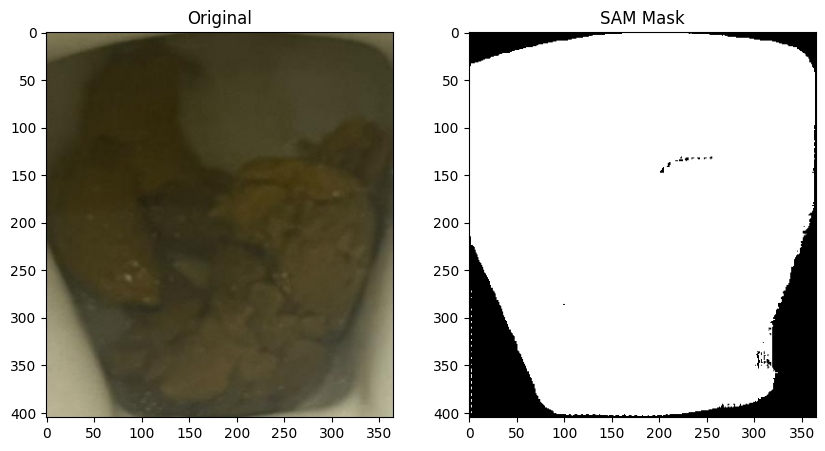

In [35]:
import matplotlib.pyplot as plt
import cv2
import os

# 檔名要換成你想看的圖
filename = "1000_jpg.rf.28f6404065f8b051e3b48385fe211624_0.jpg"
img = cv2.imread(f"/content/poop_crops/{filename}")
mask = cv2.imread(f"/content/poop_masks/{filename.replace('.jpg', '.png')}", 0)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.title("SAM Mask")
plt.imshow(mask, cmap='gray')
plt.show()

In [36]:
# 重新安裝 Segment Anything 套件
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-rn4clort
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-rn4clort
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


In [37]:
import os
import torch
import numpy as np
import cv2
from segment_anything import sam_model_registry, SamPredictor
from PIL import Image
from tqdm import tqdm

# 路徑設定
sam_checkpoint = "/content/sam_checkpoints/sam_vit_b.pth"
model_type = "vit_b"
device = "cuda" if torch.cuda.is_available() else "cpu"

# 載入 SAM 模型
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device)
predictor = SamPredictor(sam)

input_folder = "/content/poop_crops"
output_mask_folder = "/content/poop_masks"
os.makedirs(output_mask_folder, exist_ok=True)

def get_center_points(mask, num_points=5):
    """取得 mask 中心點，用來當 SAM 的提示點"""
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return []
    indices = np.linspace(0, len(xs) - 1, min(num_points, len(xs))).astype(int)
    return np.stack([xs[indices], ys[indices]], axis=1).T

# 處理每張圖片
for img_file in tqdm(os.listdir(input_folder)):
    if not img_file.lower().endswith((".jpg", ".png")):
        continue

    img_path = os.path.join(input_folder, img_file)
    image = cv2.imread(img_path)
    if image is None:
        continue
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 設定圖片
    predictor.set_image(image_rgb)

    # 設定多個提示點（中心點）
    h, w, _ = image.shape
    step = 0.2
    points = []
    for y_ratio in [0.4, 0.5, 0.6]:
        for x_ratio in [0.4, 0.5, 0.6]:
            points.append([int(w * x_ratio), int(h * y_ratio)])
    point_coords = np.array(points)
    point_labels = np.array([1] * len(points))  # 前景

    # 使用多點提示產生多個遮罩
    masks, scores, _ = predictor.predict(
        point_coords=point_coords,
        point_labels=point_labels,
        multimask_output=True
    )

    # 取最高分的遮罩
    best_mask = masks[np.argmax(scores)].astype(np.uint8) * 255

    # 儲存遮罩
    mask_name = img_file.replace(".jpg", ".png").replace(".JPG", ".png")
    cv2.imwrite(os.path.join(output_mask_folder, mask_name), best_mask)


100%|██████████| 682/682 [05:06<00:00,  2.23it/s]


In [38]:
import os

label_dir = "/content/poop_balanced_3class/valid/labels"
crop_dir = "/content/poop_crops"
output_txt = "/content/poop_crop_labels.txt"

count = 0
with open(output_txt, "w") as f:
    for img_file in os.listdir(crop_dir):
        if not img_file.endswith(".jpg"):
            continue

        base = img_file.split("_")[0]  # 例如：123_jpg
        base = base.replace("jpg.rf.", "").replace(".jpg", "").replace(".JPG", "")
        label_file = None

        # 嘗試各種可能的命名格式
        for ext in [".txt", ".TXT"]:
            test_path = os.path.join(label_dir, f"{base}.txt")
            if os.path.exists(test_path):
                label_file = test_path
                break

        if label_file is None:
            print(f"⚠️ 找不到 label：{img_file}，跳過")
            continue

        # 讀取第一個 class_id
        with open(label_file, "r") as lf:
            lines = lf.readlines()
            if len(lines) == 0:
                print(f"⚠️ label 檔是空的：{label_file}，跳過")
                continue
            class_id = lines[0].strip().split()[0]  # 只取第一個物件

        f.write(f"{img_file} {class_id}\n")
        count += 1

print(f"✅ 成功建立 {count} 筆 poop_crop_labels.txt！")

⚠️ 找不到 label：548_jpg.rf.ef5bdeadbbe731450fd3299edd99bb38_0.jpg，跳過
⚠️ 找不到 label：1059_jpg.rf.102379f5500bc9ac3a3bce917f51adcb_0.jpg，跳過
⚠️ 找不到 label：623_jpg.rf.f9531f994c6cb49340eb6213e9b38a44_4.jpg，跳過
⚠️ 找不到 label：887_jpg.rf.c17ee580cfb8a20bca8632078b65c571_0.jpg，跳過
⚠️ 找不到 label：531_jpg.rf.e16f908539171943046863bd47d1b000_0.jpg，跳過
⚠️ 找不到 label：69_jpg.rf.17ff703f23a2187f225689fa2418a729_0.jpg，跳過
⚠️ 找不到 label：606_jpg.rf.3adb84907bc2a5ecd2d645eee673522b_2.jpg，跳過
⚠️ 找不到 label：258_jpg.rf.63becbc9b1d23ee2f7bd2dc987efc25f_0.jpg，跳過
⚠️ 找不到 label：573_jpg.rf.6c27b98cfe85a3708bf64b4ee0da9708_0.jpg，跳過
⚠️ 找不到 label：1029_jpg.rf.2c58ca458f36430fa84a96fa052ee574_3.jpg，跳過
⚠️ 找不到 label：1029_jpg.rf.2c58ca458f36430fa84a96fa052ee574_0.jpg，跳過
⚠️ 找不到 label：780_jpg.rf.8879eba7a587909e734a0e162ae25c97_0.jpg，跳過
⚠️ 找不到 label：206_jpg.rf.0cdba42771637b89216f959a6605b6de_0.jpg，跳過
⚠️ 找不到 label：623_jpg.rf.f9531f994c6cb49340eb6213e9b38a44_2.jpg，跳過
⚠️ 找不到 label：485_jpg.rf.c257dded08e856438e44141ee691fc7b_0.jpg，跳過
⚠️ 找不到 l

In [39]:
import os
import shutil
from PIL import Image

image_folder = "/content/poop_crops"
mask_folder = "/content/poop_masks"
label_txt = "/content/poop_crop_labels.txt"
output_folder = "/content/poop_seg_dataset"

# 建立資料夾結構
for split in ["images", "masks", "labels"]:
    os.makedirs(f"{output_folder}/{split}", exist_ok=True)

with open(label_txt, "r") as f:
    for line in f:
        imgname, cls = line.strip().split()
        name_only = os.path.splitext(imgname)[0]

        src_img = os.path.join(image_folder, imgname)
        src_mask = os.path.join(mask_folder, imgname.replace(".jpg", ".png"))
        dst_img = os.path.join(output_folder, "images", imgname)
        dst_mask = os.path.join(output_folder, "masks", name_only + ".png")
        dst_label = os.path.join(output_folder, "labels", name_only + ".txt")

        if not os.path.exists(src_img) or not os.path.exists(src_mask):
            print(f"⚠️ 缺圖：{imgname}，跳過")
            continue

        # 複製圖片與 mask
        shutil.copy(src_img, dst_img)
        shutil.copy(src_mask, dst_mask)

        # 寫入 label
        with open(dst_label, "w") as lf:
            lf.write(f"{cls}\n")

print("✅ 完成資料集整理！")

✅ 完成資料集整理！


In [40]:
yaml_content = """
train: /content/poop_seg_dataset
val: /content/poop_seg_dataset

nc: 3
names: [Constipated, Normal, Loose]
"""

with open("/content/poop_seg_dataset/data.yaml", "w") as f:
    f.write(yaml_content.strip())

print("✅ 建立完成: data.yaml")

✅ 建立完成: data.yaml


In [41]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")
model.train(
    data="/content/poop_seg_dataset/data.yaml",
    epochs=100,
    imgsz=640,
    batch=8,
    cache=True,
    project="poop_seg_final",
    name="yolov8n-seg-sam-mask-v1"
)

Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=segment, mode=train, model=yolov8n-seg.pt, data=/content/poop_seg_dataset/data.yaml, epochs=100, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=True, device=None, workers=8, project=poop_seg_final, name=yolov8n-seg-sam-mask-v1, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, sho

train: Scanning /content/poop_seg_dataset/labels... 680 images, 713 backgrounds, 142 corrupt: 100%|██████████| 1364/1364 [00:00<00:00, 1529.86it/s]

train: /content/poop_seg_dataset/images/1042.rf.0ed96c9ec002a570077cb6c8ab8b233d_0.jpg: ignoring corrupt image/label: labels require 5 columns, 1 columns detected
train: /content/poop_seg_dataset/images/1049.rf.a570b8f63485d16ad30a9de0929ed8b8_0.jpg: ignoring corrupt image/label: labels require 5 columns, 1 columns detected
train: /content/poop_seg_dataset/images/1049.rf.a570b8f63485d16ad30a9de0929ed8b8_1.jpg: ignoring corrupt image/label: labels require 5 columns, 1 columns detected
train: /content/poop_seg_dataset/images/1053.rf.1c49036378742392a1a2957df8994468_0.jpg: ignoring corrupt image/label: labels require 5 columns, 1 columns detected
train: /content/poop_seg_dataset/images/1054.rf.15decdb91ccb6500dd885aa5e184ddf6_0.jpg: ignoring corrupt image/label: labels require 5 columns, 1 columns detected
train: /content/poop_seg_dataset/images/1062.rf.df8a09888794ae9e9234657cb87d51bb_0.jpg: ignoring corrupt image/label: labels require 5 columns, 1 columns detected
train: /content/poop_s

train: New cache created: /content/poop_seg_dataset/labels.cache
WARNING ⚠️ cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.


train: Caching images (1.0GB RAM): 100%|██████████| 1222/1222 [00:00<00:00, 2053.48it/s]

...

    100/100      4.25G      1.403      3.631      2.326      1.484          9        640: 100%|██████████| 153/153 [00:18<00:00,  8.30it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 77/77 [00:08<00:00,  8.64it/s]


                   all       1222      10838      0.265       0.05     0.0298     0.0242      0.241     0.0455     0.0263     0.0178

100 epochs completed in 0.765 hours.
Optimizer stripped from poop_seg_final/yolov8n-seg-sam-mask-v1/weights/last.pt, 6.8MB
Optimizer stripped from poop_seg_final/yolov8n-seg-sam-mask-v1/weights/best.pt, 6.8MB

Validating poop_seg_final/yolov8n-seg-sam-mask-v1/weights/best.pt...
Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,258,649 parameters, 0 gradients, 12.0 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 77/77 [00:07<00:00, 10.46it/s]


                   all       1222      10838      0.245     0.0454     0.0408     0.0284      0.208     0.0388     0.0333     0.0193
           Constipated        143       1248      0.236     0.0841     0.0561     0.0396       0.21     0.0737     0.0456     0.0267
                Normal        222       4864      0.262     0.0292     0.0325     0.0216      0.203     0.0224     0.0247     0.0133
                 Loose        144       4726      0.237     0.0229     0.0338     0.0239      0.212     0.0203     0.0297     0.0179
Speed: 0.2ms preprocess, 2.0ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to poop_seg_final/yolov8n-seg-sam-mask-v1


ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ac6e9d46450>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04

In [45]:
import numpy as np

conf_matrix = metrics.confusion_matrix.matrix
class_names = model.names

total_TP = total_FP = total_TN = total_FN = 0

for i, name in enumerate(class_names):
    TP = conf_matrix[i, i]
    FP = conf_matrix[:, i].sum() - TP
    FN = conf_matrix[i, :].sum() - TP
    TN = conf_matrix.sum() - (TP + FP + FN)

    total_TP += TP
    total_FP += FP
    total_FN += FN
    total_TN += TN

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    specificity = TN / (TN + FP + 1e-6)
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-6)
    f1_score = 2 * precision * recall / (precision + recall + 1e-6)

    print(f"📌 類別 [{name}]")
    print(f"  Precision  : {precision:.4f}")
    print(f"  Recall     : {recall:.4f}")
    print(f"  Specificity: {specificity:.4f}")
    print(f"  Accuracy   : {accuracy:.4f}")
    print(f"  F1 Score   : {f1_score:.4f}")
    print()

# 整體指標
overall_precision = total_TP / (total_TP + total_FP + 1e-6)
overall_recall = total_TP / (total_TP + total_FN + 1e-6)
overall_specificity = total_TN / (total_TN + total_FP + 1e-6)
overall_accuracy = (total_TP + total_TN) / (total_TP + total_FP + total_FN + total_TN + 1e-6)
overall_f1 = 2 * overall_precision * overall_recall / (overall_precision + overall_recall + 1e-6)

print("🔎📊 整體（Overall）指標")
print(f"  Overall Precision  : {overall_precision:.4f}")
print(f"  Overall Recall     : {overall_recall:.4f}")
print(f"  Overall Specificity: {overall_specificity:.4f}")
print(f"  Overall Accuracy   : {overall_accuracy:.4f}")
print(f"  Overall F1 Score   : {overall_f1:.4f}")

📌 類別 [0]
  Precision  : 0.1371
  Recall     : 0.7095
  Specificity: 0.8929
  Accuracy   : 0.8886
  F1 Score   : 0.2298

📌 類別 [1]
  Precision  : 0.0506
  Recall     : 0.6797
  Specificity: 0.5803
  Accuracy   : 0.5834
  F1 Score   : 0.0942

📌 類別 [2]
  Precision  : 0.0333
  Recall     : 0.7358
  Specificity: 0.5741
  Accuracy   : 0.5773
  F1 Score   : 0.0637

🔎📊 整體（Overall）指標
  Overall Precision  : 0.0537
  Overall Recall     : 0.7037
  Overall Specificity: 0.6826
  Overall Accuracy   : 0.6831
  Overall F1 Score   : 0.0997


In [42]:
!ls -R /content

串流輸出內容已截斷至最後 5000 行。
655_jpg.rf.6c47317ef6a1d3315bdebdd793054263.txt
663_jpg.rf.f8baf8167ac718c8c269706fa7cefa72.txt
677_jpg.rf.ff09f33caa83d725464732af8ab270b0.txt
67.rf.a22c4c81cf9e7898ed05c75ff352a256.txt
680_jpg.rf.8dbbf5e8a61929220f52ea5acc6908a9.txt
681_jpg.rf.f635076272543b0f335cfcf52c5cf78e.txt
682_jpg.rf.4b0786a7074529060bd51791c4e9c2cd.txt
69_jpg.rf.17ff703f23a2187f225689fa2418a729.txt
709_jpg.rf.30851fcda3e8702cb20ecef6fea05afa.txt
711_jpg.rf.24f5dcaf8380d9c6742bb6fe2f1ba15f.txt
719_jpg.rf.4508f3f25d1fbab6e32b310876ab0a5f.txt
71_jpg.rf.01e990a7464f76da2b6424d2df4de83a.txt
729_jpg.rf.aa77caaa5be1452a31e3fc8d17bc1f29.txt
72_jpg.rf.58216f6f1271a941e5aa5b2e98368e56.txt
735_jpg.rf.3a02d6bffe3fe4ae8f3f8836ac343a4f.txt
737_jpg.rf.3329256c026524cf0773ebc36aeac35c.txt
73.rf.7ec6201b6cbfe66c53df6047fc310306.txt
744_jpg.rf.1ce1f8587e0015be6657035eee68b5e2.txt
747_jpg.rf.8da698e579e7ac331a9129a09631487b.txt
755_jpg.rf.a5813376a3ae25ecc35378311791a618.txt
756_jpg.rf.317d069157f7f7e831456

In [43]:
!zip -r /content/my_colab_results.zip /content

串流輸出內容已截斷至最後 5000 行。
  adding: content/poop_dataset/poop_dataset/Loose/1367_jpg.rf.b9d854e4aaac463c74127ca6140acf70.jpg (deflated 2%)
  adding: content/poop_dataset/poop_dataset/Loose/436.rf.2ed6d623978fc97941eae393612aece3.jpg (deflated 4%)
  adding: content/poop_dataset/poop_dataset/Loose/1305_jpg.rf.696d463e5caa97a13ff6e308d1c5acc4.jpg (deflated 1%)
  adding: content/poop_dataset/poop_dataset/Loose/552_jpg.rf.344173b876813d11d0134ed94b963662.jpg (deflated 7%)
  adding: content/poop_dataset/poop_dataset/Loose/1051_jpg.rf.719fc5128d357d7375e9b593b2dc0b5f.jpg (deflated 1%)
  adding: content/poop_dataset/poop_dataset/Loose/517.rf.41fb0c222baa477ad313fabdcaba338f.jpg (deflated 2%)
  adding: content/poop_dataset/poop_dataset/Loose/44_jpg.rf.72de2015ce59411b3f61330e4bb80480.jpg (deflated 1%)
  adding: content/poop_dataset/poop_dataset/Loose/060_jpg.rf.6d0598e92fa30d84dd9bbfb7cb4acd40.jpg (deflated 2%)
  adding: content/poop_dataset/poop_dataset/Loose/1061.rf.46545a0dd9e2b1e273f04d374d1fe83

In [44]:
from google.colab import files
files.download('/content/my_colab_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # 或使用 yolov8m.pt / yolov8l.pt 提升模型能力
model.train(
    data="/content/poop_balanced_3class/data.yaml",
    epochs=200,             # 增加訓練週期
    imgsz=640,
    batch=16,               # 若 Colab Pro 記憶體夠可以加大
    name="poop_yolov8n_origin",
    project="poop_detection_origin",
    cache=True,
    device=0
)

100%|██████████| 6.25M/6.25M [00:00<00:00, 76.1MB/s]


Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/poop_balanced_3class/data.yaml, epochs=200, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=True, device=0, workers=8, project=poop_detection_origin, name=poop_yolov8n_origin, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, sho

train: Scanning /content/poop_balanced_3class/train/labels.cache... 559 images, 0 backgrounds, 0 corrupt: 100%|██████████| 559/559 [00:00<?, ?it/s]

WARNING ⚠️ cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.



train: Caching images (0.6GB RAM): 100%|██████████| 559/559 [00:00<00:00, 1221.63it/s]

...

                   all        269        654       0.83      0.673       0.78      0.628



200 epochs completed in 0.398 hours.
Optimizer stripped from poop_detection_origin/poop_yolov8n_origin/weights/last.pt, 6.3MB
Optimizer stripped from poop_detection_origin/poop_yolov8n_origin/weights/best.pt, 6.3MB

Validating poop_detection_origin/poop_yolov8n_origin/weights/best.pt...
Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:02<00:00,  3.52it/s]


                   all        269        654      0.807      0.682       0.78      0.628
           Constipated         46        170      0.834      0.799       0.87      0.733
                Normal        126        283      0.754      0.576      0.693      0.533
                 Loose        116        201      0.833      0.672      0.777       0.62
Speed: 0.2ms preprocess, 2.0ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to poop_detection_origin/poop_yolov8n_origin


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ac4d1635e90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [49]:
!ls /content/runs/detect/

train  val


In [50]:
!ls /content/runs/detect/train/weights/

best.pt  last.pt


In [53]:
!pip install ultralytics --upgrade
from ultralytics import YOLO
import numpy as np
model = YOLO("runs/detect/train/weights/best.pt")
metrics = model.val(data="poop_balanced_3class/data.yaml", save_json=True)
conf_matrix = metrics.confusion_matrix.matrix
class_names = model.names

total_TP = total_FP = total_TN = total_FN = 0

for i, name in enumerate(class_names):
    TP = conf_matrix[i, i]
    FP = conf_matrix[:, i].sum() - TP
    FN = conf_matrix[i, :].sum() - TP
    TN = conf_matrix.sum() - (TP + FP + FN)

    total_TP += TP
    total_FP += FP
    total_FN += FN
    total_TN += TN

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    specificity = TN / (TN + FP + 1e-6)
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-6)
    f1_score = 2 * precision * recall / (precision + recall + 1e-6)

    print(f"📌 類別 [{name}]")
    print(f"  Precision  : {precision:.4f}")
    print(f"  Recall     : {recall:.4f}")
    print(f"  Specificity: {specificity:.4f}")
    print(f"  Accuracy   : {accuracy:.4f}")
    print(f"  F1 Score   : {f1_score:.4f}")
    print()
overall_precision = total_TP / (total_TP + total_FP + 1e-6)
overall_recall = total_TP / (total_TP + total_FN + 1e-6)
overall_specificity = total_TN / (total_TN + total_FP + 1e-6)
overall_accuracy = (total_TP + total_TN) / (total_TP + total_FP + total_FN + total_TN + 1e-6)
overall_f1 = 2 * overall_precision * overall_recall / (overall_precision + overall_recall + 1e-6)

print("🔎📊 整體（Overall）指標")
print(f"  Overall Precision  : {overall_precision:.4f}")
print(f"  Overall Recall     : {overall_recall:.4f}")
print(f"  Overall Specificity: {overall_specificity:.4f}")
print(f"  Overall Accuracy   : {overall_accuracy:.4f}")
print(f"  Overall F1 Score   : {overall_f1:.4f}")

Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1157.6±419.2 MB/s, size: 32.8 KB)


val: Scanning /content/poop_balanced_3class/valid/labels.cache... 269 images, 0 backgrounds, 0 corrupt: 100%|██████████| 269/269 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:07<00:00,  2.20it/s]


                   all        269        654      0.831      0.744      0.819      0.677
           Constipated         46        170      0.884      0.851      0.911       0.76
                Normal        126        283      0.812      0.658      0.753       0.61
                 Loose        116        201      0.795      0.721      0.793       0.66
Speed: 0.9ms preprocess, 22.5ms inference, 0.0ms loss, 0.9ms postprocess per image
Saving runs/detect/val4/predictions.json...
Results saved to runs/detect/val4
📌 類別 [0]
  Precision  : 0.8588
  Recall     : 0.7449
  Specificity: 0.9617
  Accuracy   : 0.9101
  F1 Score   : 0.7978

📌 類別 [1]
  Precision  : 0.6961
  Recall     : 0.6747
  Specificity: 0.8380
  Accuracy   : 0.7801
  F1 Score   : 0.6852

📌 類別 [2]
  Precision  : 0.7264
  Recall     : 0.6759
  Specificity: 0.9094
  Accuracy   : 0.8481
  F1 Score   : 0.7002

🔎📊 整體（Overall）指標
  Overall Precision  : 0.7477
  Overall Recall     : 0.6946
  Overall Specificity: 0.9065
  Overall Accura

In [54]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")  # 或使用 yolov8m.pt / yolov8l.pt 提升模型能力
model.train(
    data="/content/poop_balanced_3class/data.yaml",
    epochs=200,             # 增加訓練週期
    imgsz=640,
    batch=16,               # 若 Colab Pro 記憶體夠可以加大
    name="poop_yolov8n_origin2",
    project="poop_detection_origin2",
    cache=True,
    device=0
)

Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/poop_balanced_3class/data.yaml, epochs=200, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=True, device=0, workers=8, project=poop_detection_origin2, name=poop_yolov8n_origin2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, s

train: Scanning /content/poop_balanced_3class/train/labels.cache... 559 images, 0 backgrounds, 0 corrupt: 100%|██████████| 559/559 [00:00<?, ?it/s]

WARNING ⚠️ cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.



train: Caching images (0.6GB RAM): 100%|██████████| 559/559 [00:00<00:00, 1761.14it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

                   all        269        654      0.803      0.715      0.771      0.644



200 epochs completed in 1.261 hours.
Optimizer stripped from poop_detection_origin2/poop_yolov8n_origin2/weights/last.pt, 52.1MB
Optimizer stripped from poop_detection_origin2/poop_yolov8n_origin2/weights/best.pt, 52.1MB

Validating poop_detection_origin2/poop_yolov8n_origin2/weights/best.pt...
Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:03<00:00,  2.35it/s]


                   all        269        654      0.804      0.714      0.771      0.644
           Constipated         46        170      0.834      0.796      0.843      0.727
                Normal        126        283      0.756      0.636      0.714      0.582
                 Loose        116        201      0.822       0.71      0.755      0.624
Speed: 0.2ms preprocess, 9.9ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to poop_detection_origin2/poop_yolov8n_origin2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ac54ae2f850>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [56]:
from ultralytics import YOLO
import numpy as np

# ✅ 載入訓練完成的最佳模型
model = YOLO("/content/poop_detection_origin2/poop_yolov8n_origin22/weights/best.pt")

# ✅ 驗證模型並產生混淆矩陣
results = model.val(data="/content/poop_balanced_3class/data.yaml", save_json=True)

# ✅ 取得混淆矩陣與類別
conf_matrix = results.confusion_matrix.matrix
class_names = model.names

# ✅ 計算每一類別與整體指標
total_TP = total_FP = total_FN = total_TN = 0

for i, name in enumerate(class_names):
    TP = conf_matrix[i, i]
    FP = conf_matrix[:, i].sum() - TP
    FN = conf_matrix[i, :].sum() - TP
    TN = conf_matrix.sum() - (TP + FP + FN)

    total_TP += TP
    total_FP += FP
    total_FN += FN
    total_TN += TN

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    specificity = TN / (TN + FP + 1e-6)
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-6)
    f1_score = 2 * precision * recall / (precision + recall + 1e-6)

    print(f"📌 類別 [{name}]")
    print(f"  Precision  : {precision:.4f}")
    print(f"  Recall     : {recall:.4f}")
    print(f"  Specificity: {specificity:.4f}")
    print(f"  Accuracy   : {accuracy:.4f}")
    print(f"  F1 Score   : {f1_score:.4f}")
    print()

# ✅ 整體指標計算
overall_precision = total_TP / (total_TP + total_FP + 1e-6)
overall_recall = total_TP / (total_TP + total_FN + 1e-6)
overall_specificity = total_TN / (total_TN + total_FP + 1e-6)
overall_accuracy = (total_TP + total_TN) / (total_TP + total_FP + total_FN + total_TN + 1e-6)
overall_f1 = 2 * overall_precision * overall_recall / (overall_precision + overall_recall + 1e-6)

print("🔎📊 整體（Overall）指標")
print(f"  Overall Precision  : {overall_precision:.4f}")
print(f"  Overall Recall     : {overall_recall:.4f}")
print(f"  Overall Specificity: {overall_specificity:.4f}")
print(f"  Overall Accuracy   : {overall_accuracy:.4f}")
print(f"  Overall F1 Score   : {overall_f1:.4f}")


Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 680.4±246.2 MB/s, size: 29.4 KB)


val: Scanning /content/poop_balanced_3class/valid/labels.cache... 269 images, 0 backgrounds, 0 corrupt: 100%|██████████| 269/269 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:07<00:00,  2.26it/s]


                   all        269        654      0.822      0.719      0.786      0.654
           Constipated         46        170      0.897       0.77      0.863      0.746
                Normal        126        283      0.733      0.669       0.72      0.584
                 Loose        116        201      0.835      0.716      0.774      0.633
Speed: 0.9ms preprocess, 21.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Saving runs/detect/val5/predictions.json...
Results saved to runs/detect/val5
📌 類別 [0]
  Precision  : 0.8000
  Recall     : 0.7556
  Specificity: 0.9481
  Accuracy   : 0.9066
  F1 Score   : 0.7771

📌 類別 [1]
  Precision  : 0.6784
  Recall     : 0.6057
  Specificity: 0.8243
  Accuracy   : 0.7413
  F1 Score   : 0.6400

📌 類別 [2]
  Precision  : 0.7313
  Recall     : 0.6837
  Specificity: 0.9129
  Accuracy   : 0.8539
  F1 Score   : 0.7067

🔎📊 整體（Overall）指標
  Overall Precision  : 0.7263
  Overall Recall     : 0.6671
  Overall Specificity: 0.9002
  Overall Accura

In [58]:
from ultralytics import YOLO
import numpy as np

# ✅ 載入 yolov8n 訓練完成的最佳模型
model = YOLO("/content/poop_detection_origin/poop_yolov8n_origin/weights/best.pt")

# ✅ 驗證模型（用 valid 資料集）
results = model.val(data="/content/poop_balanced_3class/data.yaml", save_json=True)

# ✅ 取得混淆矩陣與類別名稱
conf_matrix = results.confusion_matrix.matrix
class_names = model.names

# ✅ 計算每一類別與整體指標
total_TP = total_FP = total_FN = total_TN = 0

for i, name in enumerate(class_names):
    TP = conf_matrix[i, i]
    FP = conf_matrix[:, i].sum() - TP
    FN = conf_matrix[i, :].sum() - TP
    TN = conf_matrix.sum() - (TP + FP + FN)

    total_TP += TP
    total_FP += FP
    total_FN += FN
    total_TN += TN

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    specificity = TN / (TN + FP + 1e-6)
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-6)
    f1_score = 2 * precision * recall / (precision + recall + 1e-6)

    print(f"📌 類別 [{name}]")
    print(f"  Precision  : {precision:.4f}")
    print(f"  Recall     : {recall:.4f}")
    print(f"  Specificity: {specificity:.4f}")
    print(f"  Accuracy   : {accuracy:.4f}")
    print(f"  F1 Score   : {f1_score:.4f}")
    print()

# ✅ 整體指標計算
overall_precision = total_TP / (total_TP + total_FP + 1e-6)
overall_recall = total_TP / (total_TP + total_FN + 1e-6)
overall_specificity = total_TN / (total_TN + total_FP + 1e-6)
overall_accuracy = (total_TP + total_TN) / (total_TP + total_FP + total_FN + total_TN + 1e-6)
overall_f1 = 2 * overall_precision * overall_recall / (overall_precision + overall_recall + 1e-6)

print("🔎📊 整體（Overall）指標")
print(f"  Overall Precision  : {overall_precision:.4f}")
print(f"  Overall Recall     : {overall_recall:.4f}")
print(f"  Overall Specificity: {overall_specificity:.4f}")
print(f"  Overall Accuracy   : {overall_accuracy:.4f}")
print(f"  Overall F1 Score   : {overall_f1:.4f}")

Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1001.1±365.4 MB/s, size: 29.7 KB)


val: Scanning /content/poop_balanced_3class/valid/labels.cache... 269 images, 0 backgrounds, 0 corrupt: 100%|██████████| 269/269 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:03<00:00,  4.95it/s]


                   all        269        654      0.806      0.682       0.78      0.629
           Constipated         46        170      0.834        0.8       0.87      0.733
                Normal        126        283       0.75      0.576      0.693      0.532
                 Loose        116        201      0.833      0.672      0.777      0.621
Speed: 0.9ms preprocess, 4.0ms inference, 0.0ms loss, 3.1ms postprocess per image
Saving runs/detect/val6/predictions.json...
Results saved to runs/detect/val6
📌 類別 [0]
  Precision  : 0.8176
  Recall     : 0.7277
  Specificity: 0.9532
  Accuracy   : 0.9027
  F1 Score   : 0.7701

📌 類別 [1]
  Precision  : 0.6290
  Recall     : 0.6075
  Specificity: 0.8125
  Accuracy   : 0.7421
  F1 Score   : 0.6181

📌 類別 [2]
  Precision  : 0.7413
  Recall     : 0.6395
  Specificity: 0.9161
  Accuracy   : 0.8406
  F1 Score   : 0.6866

🔎📊 整體（Overall）指標
  Overall Precision  : 0.7125
  Overall Recall     : 0.6499
  Overall Specificity: 0.8979
  Overall Accurac

In [59]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")  # 或使用 yolov8m.pt / yolov8l.pt 提升模型能力
model.train(
    data="/content/poop_balanced_3class/data.yaml",
    epochs=200,             # 增加訓練週期
    imgsz=640,
    batch=16,               # 若 Colab Pro 記憶體夠可以加大
    name="poop_yolov8n_origin3",
    project="poop_detection_origin3",
    cache=True,
    device=0
)

Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/poop_balanced_3class/data.yaml, epochs=200, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=True, device=0, workers=8, project=poop_detection_origin3, name=poop_yolov8n_origin3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, s

train: Scanning /content/poop_balanced_3class/train/labels.cache... 559 images, 0 backgrounds, 0 corrupt: 100%|██████████| 559/559 [00:00<?, ?it/s]

WARNING ⚠️ cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.



train: Caching images (0.6GB RAM): 100%|██████████| 559/559 [00:00<00:00, 946.44it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

    200/200      6.76G     0.3862     0.3217     0.9157         26        640: 100%|██████████| 35/35 [00:17<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:03<00:00,  2.44it/s]


                   all        269        654      0.862      0.702      0.788      0.657

200 epochs completed in 1.262 hours.
Optimizer stripped from poop_detection_origin3/poop_yolov8n_origin3/weights/last.pt, 52.1MB
Optimizer stripped from poop_detection_origin3/poop_yolov8n_origin3/weights/best.pt, 52.1MB

Validating poop_detection_origin3/poop_yolov8n_origin3/weights/best.pt...
Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:04<00:00,  2.22it/s]


                   all        269        654      0.862      0.702      0.788      0.657
           Constipated         46        170      0.877      0.796      0.873      0.742
                Normal        126        283      0.848      0.593      0.709      0.579
                 Loose        116        201      0.861      0.716      0.782       0.65
Speed: 0.2ms preprocess, 10.0ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to poop_detection_origin3/poop_yolov8n_origin3


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ac5c7eaff90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [61]:
# ✅ STEP 2: 載入訓練完成模型（best.pt）
model = YOLO("/content/poop_detection_origin3/poop_yolov8n_origin3/weights/best.pt")

# ✅ STEP 3: 驗證模型效能
results = model.val(data="/content/poop_balanced_3class/data.yaml", save_json=True)

# ✅ STEP 4: 計算每一類別與整體指標
conf_matrix = results.confusion_matrix.matrix
class_names = model.names

total_TP = total_FP = total_FN = total_TN = 0

for i, name in enumerate(class_names):
    TP = conf_matrix[i, i]
    FP = conf_matrix[:, i].sum() - TP
    FN = conf_matrix[i, :].sum() - TP
    TN = conf_matrix.sum() - (TP + FP + FN)

    total_TP += TP
    total_FP += FP
    total_FN += FN
    total_TN += TN

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    specificity = TN / (TN + FP + 1e-6)
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-6)
    f1_score = 2 * precision * recall / (precision + recall + 1e-6)

    print(f"📌 類別 [{name}]")
    print(f"  Precision  : {precision:.4f}")
    print(f"  Recall     : {recall:.4f}")
    print(f"  Specificity: {specificity:.4f}")
    print(f"  Accuracy   : {accuracy:.4f}")
    print(f"  F1 Score   : {f1_score:.4f}")
    print()

# ✅ STEP 5: 整體指標計算
overall_precision = total_TP / (total_TP + total_FP + 1e-6)
overall_recall = total_TP / (total_TP + total_FN + 1e-6)
overall_specificity = total_TN / (total_TN + total_FP + 1e-6)
overall_accuracy = (total_TP + total_TN) / (total_TP + total_FP + total_FN + total_TN + 1e-6)
overall_f1 = 2 * overall_precision * overall_recall / (overall_precision + overall_recall + 1e-6)

print("🔎📊 整體（Overall）指標")
print(f"  Overall Precision  : {overall_precision:.4f}")
print(f"  Overall Recall     : {overall_recall:.4f}")
print(f"  Overall Specificity: {overall_specificity:.4f}")
print(f"  Overall Accuracy   : {overall_accuracy:.4f}")
print(f"  Overall F1 Score   : {overall_f1:.4f}")


Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 820.3±321.1 MB/s, size: 29.4 KB)


val: Scanning /content/poop_balanced_3class/valid/labels.cache... 269 images, 0 backgrounds, 0 corrupt: 100%|██████████| 269/269 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:07<00:00,  2.24it/s]


                   all        269        654      0.861      0.702      0.788      0.657
           Constipated         46        170      0.877      0.796      0.872      0.742
                Normal        126        283      0.849      0.594      0.709      0.579
                 Loose        116        201      0.858      0.716      0.783       0.65
Speed: 0.9ms preprocess, 22.1ms inference, 0.0ms loss, 0.9ms postprocess per image
Saving runs/detect/val7/predictions.json...
Results saved to runs/detect/val7
📌 類別 [0]
  Precision  : 0.8353
  Recall     : 0.7513
  Specificity: 0.9545
  Accuracy   : 0.9067
  F1 Score   : 0.7911

📌 類別 [1]
  Precision  : 0.6325
  Recall     : 0.6348
  Specificity: 0.8008
  Accuracy   : 0.7425
  F1 Score   : 0.6336

📌 類別 [2]
  Precision  : 0.7612
  Recall     : 0.7321
  Specificity: 0.9193
  Accuracy   : 0.8706
  F1 Score   : 0.7463

🔎📊 整體（Overall）指標
  Overall Precision  : 0.7248
  Overall Recall     : 0.6971
  Overall Specificity: 0.8961
  Overall Accura

In [62]:
!ls -R /content
!zip -r /content/my_colab_results2.zip /content
from google.colab import files
files.download('/content/my_colab_results2.zip')

串流輸出內容已截斷至最後 5000 行。
  adding: content/yolo_outputs/1314_jpg.rf.f3617e2f82a58097ecb8151d97c21e49_crop3.jpg (deflated 12%)
  adding: content/yolo_outputs/172_jpg.rf.a0662815e99aaa7aa0dc430a4ac65d7a_crop1.jpg (deflated 1%)
  adding: content/yolo_outputs/614_jpg.rf.803c642748e3f2e9ececb9a42527aacb_crop4.jpg (deflated 1%)
  adding: content/yolo_outputs/193_jpg.rf.13919c87167d85f36ea739c683515faa_crop0.jpg (deflated 0%)
  adding: content/yolo_outputs/1322_jpg.rf.4c026b729c474087bf9b5c4cd6327781_crop4.jpg (deflated 17%)
  adding: content/yolo_outputs/1029_jpg.rf.2c58ca458f36430fa84a96fa052ee574_crop0.jpg (deflated 1%)
  adding: content/yolo_outputs/803_jpg.rf.74b5c69027b986614e916432e9010c5a_crop5.jpg (deflated 2%)
  adding: content/yolo_outputs/636.rf.e14ee41c7fc33b4feb81aeaf3b2dce9b_crop0.jpg (deflated 1%)
  adding: content/yolo_outputs/217_jpg.rf.ca71bfba9b0527548b0ae6cf5ee5538b_crop0.jpg (deflated 5%)
  adding: content/yolo_outputs/737_jpg.rf.3329256c026524cf0773ebc36aeac35c_crop10.jpg (

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>